# RoomBeacon — Rental Price Benchmark V3: Methodology-Hardened

This benchmark predicts `price_amount_clean` from canonical Silver. Model/feature/transform/tuning choices use **development chronological folds only**. The final chronological TEST is sealed until one candidate is locked. No Bronze/Silver logic is changed.

## 01 Runtime, canonical input, and reproducibility

In [37]:
from pathlib import Path
from datetime import datetime, timezone
import json, platform, sys, time
PROJECT_ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'crawler').is_dir() and (p/'analytics').is_dir())
sys.path.insert(0,str(PROJECT_ROOT))
import duckdb,numpy as np,pandas as pd,matplotlib.pyplot as plt
import sklearn,xgboost,lightgbm,catboost
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from IPython.display import display,Markdown
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor,GradientBoostingRegressor,HistGradientBoostingRegressor,RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet,LinearRegression,Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.tree import DecisionTreeRegressor
from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.modeling_benchmark import *
from notebooks.utils.modeling_benchmark import prepare_lightgbm_categories
from notebooks.utils.listing_semantics import BUSINESS_TARGET_DEFINITION,semantic_model_eligibility
SEED=42; np.random.seed(SEED); plt.style.use('seaborn-v0_8-whitegrid')
SILVER_PATH=resolve_runtime_path(env.processing.silver_dir)/'rental_listings.parquet'
METADATA_PATH=resolve_runtime_path(env.processing.silver_dir)/'rental_listings.metadata.json'
with duckdb.connect(':memory:') as con: silver_df=con.execute('select * from read_parquet(?)',[str(SILVER_PATH)]).df()
silver_metadata=json.loads(METADATA_PATH.read_text())
assert len(silver_df)==silver_df.rental_post_id.nunique()==silver_metadata['row_count']
versions={'Python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,'scikit-learn':sklearn.__version__,'xgboost':xgboost.__version__,'lightgbm':lightgbm.__version__,'catboost':catboost.__version__}
display(pd.Series(versions,name='Version').to_frame())

ImportError: cannot import name 'prepare_lightgbm_categories' from 'notebooks.utils.modeling_benchmark' (/data/projects/roombeacon/source/roombeacon-system/notebooks/utils/modeling_benchmark.py)

## 02 Business target, semantic population, and leakage contract

**Business target:** Predict the asking rental price for an ordinary individual rental listing/unit represented by RoomBeacon.

SALE, TRANSFER, WHOLE_BUILDING, and MULTI_UNIT_BUSINESS evidence is incompatible. UNKNOWN is retained when no conflicting evidence exists; sparse text is not guessed. Semantic labels are eligibility/audit fields and are not predictors.

,Policy
Business target,Predict the asking rental price for an ordinar...
UNKNOWN policy,Retain unless conflicting SALE/TRANSFER/aggreg...


,Population,Rows,Percent of Silver
0,Total Silver,132436,100.000000
1,Numeric price eligible,128051,96.688967
2,Semantic model eligible,127375,96.178532
3,Semantic exclusions among numeric eligible,676,0.510435


,Rows
listing_intent,
RENT,92266
UNKNOWN,39649
TRANSFER,300
SALE,221


,Rows
rental_scope,
SINGLE_OR_ORDINARY_UNIT,92496
UNKNOWN,39762
MULTI_UNIT_BUSINESS,177
WHOLE_BUILDING,1


,listing_intent,rental_scope,semantic_eligibility_reason,source_code,Rows
18,TRANSFER,SINGLE_OR_ORDINARY_UNIT,EXCLUDE_TRANSFER,phongtro123,250
11,SALE,UNKNOWN,EXCLUDE_SALE,phongtro123,144
20,UNKNOWN,MULTI_UNIT_BUSINESS,EXCLUDE_MULTI_UNIT_BUSINESS,chothuephongtro,49
23,UNKNOWN,MULTI_UNIT_BUSINESS,EXCLUDE_MULTI_UNIT_BUSINESS,phongtro123,46
3,RENT,MULTI_UNIT_BUSINESS,EXCLUDE_MULTI_UNIT_BUSINESS,phongtro123,34
7,SALE,UNKNOWN,EXCLUDE_SALE,cafeland,22
9,SALE,UNKNOWN,EXCLUDE_SALE,mogi,22
8,SALE,UNKNOWN,EXCLUDE_SALE,chothuephongtro,20
16,TRANSFER,SINGLE_OR_ORDINARY_UNIT,EXCLUDE_TRANSFER,mogi,19
15,TRANSFER,SINGLE_OR_ORDINARY_UNIT,EXCLUDE_TRANSFER,chothuephongtro,11


...

,rental_post_id,source_code,title_clean,price_amount_clean,area_value_clean,listing_intent,listing_intent_reason,listing_intent_evidence,rental_scope,rental_scope_reason,rental_scope_evidence,semantic_eligibility_reason
341,53939,cafeland,Phòng trọ: ban công mặt tiền – ngay đh công th...,3.900000e+06,30.0,SALE,TITLE_EXPLICIT_SALE,phong tro: ban,UNKNOWN,INSUFFICIENT_SCOPE_EVIDENCE,,EXCLUDE_SALE
356,53954,chothuenha,Phòng CHDV 2 phòng ngủ 1 phòng khách full nội ...,5.800000e+06,NaN,UNKNOWN,INSUFFICIENT_TITLE_EVIDENCE,,MULTI_UNIT_BUSINESS,TITLE_MULTI_ROOM_AGGREGATE,chdv 2 phong ngu 1 phong,EXCLUDE_MULTI_UNIT_BUSINESS
417,54015,chothuenha,SANG HỢP ĐỒNG PHÒNG TRỌ 35M² – VIEW LANDMARK 8...,6.300000e+06,NaN,TRANSFER,TITLE_EXPLICIT_CONTRACT_TRANSFER,sang hop dong,SINGLE_OR_ORDINARY_UNIT,TITLE_ORDINARY_UNIT_NO_AGGREGATE_EVIDENCE,phong tro,EXCLUDE_TRANSFER
481,54079,chothuenha,Cần sang nhượng lại phòng như hình,7.000000e+06,NaN,TRANSFER,TITLE_EXPLICIT_CONTRACT_TRANSFER,sang nhuong,SINGLE_OR_ORDINARY_UNIT,TITLE_ORDINARY_UNIT_NO_AGGREGATE_EVIDENCE,sang nhuong,EXCLUDE_TRANSFER
526,54124,chothuenha,Sang lại Phòng Tầng trệt full nội thất 35m² tạ...,4.000000e+06,NaN,TRANSFER,TITLE_EXPLICIT_TRANSFER,sang lai,SINGLE_OR_ORDINARY_UNIT,TITLE_ORDINARY_UNIT_NO_AGGREGATE_EVIDENCE,sang lai,EXCLUDE_TRANSFER
615,54213,cafeland,Phòng trọ: ban Công rộng ...3tr9... Giá Rẻ ko ...,3.900000e+06,30.0,SALE,TITLE_EXPLICIT_SALE,phong tro: ban,UNKNOWN,INSUFFICIENT_SCOPE_EVIDENCE,,EXCLUDE_SALE
1091,55427,phongtro123,BAN CÔNG 30m2 FULL NỘI THẤT AN DƯƠNG VƯƠNG Q5,5.700000e+06,30.0,SALE,TITLE_EXPLICIT_SALE,ban,UNKNOWN,INSUFFICIENT_SCOPE_EVIDENCE,,EXCLUDE_SALE
2689,59091,mogi,"Khai Trương CHDV 2 Phòng Ngủ, 1 Sân Vườn",7.000000e+06,40.0,UNKNOWN,INSUFFICIENT_TITLE_EVIDENCE,,MULTI_UNIT_BUSINESS,TITLE_MULTI_ROOM_AGGREGATE,chdv 2 phong,EXCLUDE_MULTI_UNIT_BUSINESS
3917,60645,phongtro123,Ban Công Lớn - Full NT - Ni Sư Huỳnh Liên - Gi...,4.600000e+06,25.0,SALE,TITLE_EXPLICIT_SALE,ban,UNKNOWN,INSUFFICIENT_SCOPE_EVIDENCE,,EXCLUDE_SALE
3919,60647,phongtro123,Ban Công Lớn - Lê Văn Huân - ETOWN Cộng Hòa - ...,5.400000e+06,27.0,SALE,TITLE_EXPLICIT_SALE,ban,UNKNOWN,INSUFFICIENT_SCOPE_EVIDENCE,,EXCLUDE_SALE


### Valid high-price rows retained by semantic evidence

,rental_post_id,source_code,title_clean,price_amount_clean,area_value_clean,listing_intent,rental_scope
104152,239480,phongtro123,phòng trọ cho thuê có gác giá 3800k quận bình ...,3.800000e+10,25.0,RENT,SINGLE_OR_ORDINARY_UNIT
68213,165585,phongtro123,CHO THUÊ CĂN HỘ 2PN1WC VINHOMES QUẬN 9,8.500000e+09,59.0,RENT,SINGLE_OR_ORDINARY_UNIT
102101,236152,phongtro123,PHÒNG CHO THUÊ Q3 KHÔNG GIỚI HẠN NGƯỜI Ở,5.500000e+09,40.0,RENT,SINGLE_OR_ORDINARY_UNIT
72393,175339,phongtro123,Gác siêu thoáng - dương quảng hàm,4.500000e+09,30.0,UNKNOWN,UNKNOWN
24992,85795,mogi,Cho thuê phòng trọ FULL nội thất ngay ngã tư T...,4.000000e+09,20.0,RENT,SINGLE_OR_ORDINARY_UNIT
42279,106544,nhatot,Mô tả chi tiết,4.000000e+09,25.0,UNKNOWN,UNKNOWN
104097,239425,phongtro123,Cho thuê nhà trọ giá 3tr7 tại nguyễn thị thập,3.700000e+09,25.0,RENT,SINGLE_OR_ORDINARY_UNIT
104143,239471,phongtro123,"Phòng tiện nghi cao cấp- giá bình dân, Được nấ...",3.500000e+09,25.0,UNKNOWN,UNKNOWN
102951,238002,phongtro123,Phòng 16m2 giá 2.400k cho 2-3 bạn nữ ở. Tới sa...,2.400000e+09,16.0,UNKNOWN,UNKNOWN
104164,239492,phongtro123,"Cho CBCNV &amp; SV thuê, được nấu ăn, giờ giấc...",2.200000e+09,24.0,UNKNOWN,UNKNOWN


,Feature Set,Features
0,F1 — AREA ONLY,area_value_clean
1,F2 — AREA + SOURCE,"area_value_clean, source_code"
2,F3 — AREA + LOCATION,"area_value_clean, ward_current, district_text_..."
3,F4 — AREA + SOURCE + LOCATION,"area_value_clean, source_code, ward_current, d..."
4,F5 — FULL SAFE TABULAR,"area_value_clean, source_code, ward_current, d..."


**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, parser/quality fields, and every target-reconstructive field are excluded.

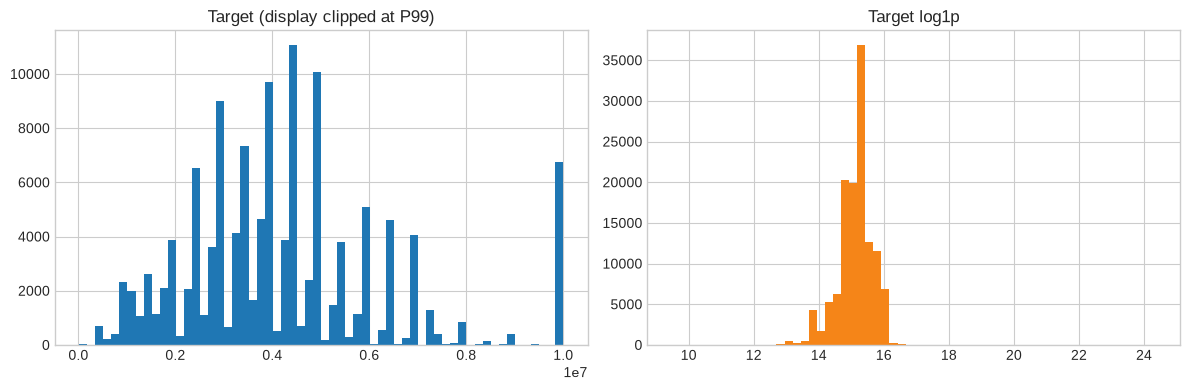

In [ ]:
prepared=engineer_safe_features(silver_df)
numeric_eligible=prepared[TARGET].notna()&prepared[TARGET].gt(0)&~prepared.price_quality_status.eq('MISSING_OR_REVIEW')
semantic_compatible,semantic_reason=semantic_model_eligibility(prepared); prepared['semantic_eligibility_reason']=semantic_reason
eligible=numeric_eligible&semantic_compatible
model_df=prepared.loc[eligible].copy(); model_df['group_key']=build_group_key(model_df)
FEATURE_SETS=build_feature_sets(model_df.columns)
for features in FEATURE_SETS.values(): audit_features(features)
before=prepared.loc[numeric_eligible,TARGET].astype(float); target=model_df[TARGET].astype(float)
semantic_population_summary=pd.DataFrame([{'Population':'Total Silver','Rows':len(prepared)},{'Population':'Numeric price eligible','Rows':int(numeric_eligible.sum())},{'Population':'Semantic model eligible','Rows':len(model_df)},{'Population':'Semantic exclusions among numeric eligible','Rows':int((numeric_eligible&~semantic_compatible).sum())}]); semantic_population_summary['Percent of Silver']=semantic_population_summary.Rows/len(prepared)*100
semantic_exclusion_summary=prepared.loc[numeric_eligible&~semantic_compatible].groupby(['listing_intent','rental_scope','semantic_eligibility_reason','source_code'],dropna=False).size().rename('Rows').reset_index().sort_values('Rows',ascending=False)
target_distribution_comparison=pd.DataFrame([{'Population':'Before semantic filtering','Rows':len(before),'Median':before.median(),'P95':before.quantile(.95),'P99':before.quantile(.99),'Max':before.max()},{'Population':'After semantic filtering','Rows':len(target),'Median':target.median(),'P95':target.quantile(.95),'P99':target.quantile(.99),'Max':target.max()}])
semantic_exclusion_examples=prepared.loc[numeric_eligible&~semantic_compatible,['rental_post_id','source_code','title_clean',TARGET,'area_value_clean','listing_intent','listing_intent_reason','listing_intent_evidence','rental_scope','rental_scope_reason','rental_scope_evidence','semantic_eligibility_reason']].groupby('semantic_eligibility_reason',group_keys=False).head(8)
valid_high_price_examples=prepared.loc[eligible,['rental_post_id','source_code','title_clean',TARGET,'area_value_clean','listing_intent','rental_scope']].nlargest(20,TARGET)
display(pd.Series({'Business target':BUSINESS_TARGET_DEFINITION,'UNKNOWN policy':'Retain unless conflicting SALE/TRANSFER/aggregate evidence exists'},name='Policy').to_frame()); display(semantic_population_summary); display(prepared.listing_intent.value_counts(dropna=False).to_frame('Rows')); display(prepared.rental_scope.value_counts(dropna=False).to_frame('Rows')); display(semantic_exclusion_summary); display(target_distribution_comparison); display(semantic_exclusion_examples); display(Markdown('### Valid high-price rows retained by semantic evidence')); display(valid_high_price_examples)
display(pd.DataFrame([{'Feature Set':k,'Features':', '.join(v)} for k,v in FEATURE_SETS.items()]))
display(Markdown('**Leakage exclusions:** identifiers, duplicate group keys, raw/canonical price evidence, `price_per_area`, parser/quality fields, and every target-reconstructive field are excluded.'))
q=target.quantile([.01,.5,.95,.99])
fig,ax=plt.subplots(1,2,figsize=(12,4)); ax[0].hist(target.clip(upper=q.loc[.99]),bins=60); ax[1].hist(np.log1p(target),bins=60,color='#F58518'); ax[0].set_title('Target (display clipped at P99)'); ax[1].set_title('Target log1p'); plt.tight_layout(); plt.show()

## 03 Sealed strict group-chronological split

In [ ]:
split_result=group_aware_split(model_df,model_df.group_key,seed=SEED)
model_df['split']=split_result.labels; assert_group_isolation(model_df.group_key,model_df.split); assert_split_chronology(model_df,model_df.group_key,split_result)
development_df=model_df.loc[model_df.split.ne('TEST')].copy(); test_df=model_df.loc[model_df.split.eq('TEST')].copy()
folds=build_expanding_group_time_folds(development_df,development_df.group_key,n_splits=3)
split_report=model_df.groupby('split').agg(Rows=('rental_post_id','size'),Groups=('group_key','nunique'),Target_Median=(TARGET,'median'),Target_P95=(TARGET,lambda x:x.quantile(.95)),Target_Max=(TARGET,'max'),Min_Time=('latest_observed_at','min'),Max_Time=('latest_observed_at','max')).reindex(['TRAIN','VALIDATION','TEST'])
fold_report=pd.DataFrame([{'Fold':f.fold,'Train Rows':len(f.train_index),'Validation Rows':len(f.validation_index),'Train Groups':f.train_groups,'Validation Groups':f.validation_groups,'Train Start':f.train_start,'Train End':f.train_end,'Validation Start':f.validation_start,'Validation End':f.validation_end} for f in folds])
display(pd.Series({'Strategy':split_result.strategy,'Reason':split_result.reason,'Limitation':'Only ~10 days: short-window future evidence, not long-term generalization'},name='Value').to_frame()); display(split_report); display(fold_report)
TEST_ACCESSED_FOR_SELECTION=False

,Value
Strategy,GROUP_LEVEL_CHRONOLOGICAL_70_15_15
Reason,Whole duplicate groups ordered by representati...
Limitation,"Only ~10 days: short-window future evidence, n..."


,Rows,Groups,Target_Median,Target_P95,Target_Max,Min_Time,Max_Time
split,,,,,,,
TRAIN,87935,86968,4200000.0,10000000.0,3.800000e+10,2026-09-20 12:48:44,2026-09-28 14:01:01
VALIDATION,20738,18652,3900000.0,6800000.0,2.500000e+08,2026-09-21 05:10:12,2026-09-29 12:38:36
TEST,18702,18620,3600000.0,6200000.0,9.500000e+07,2026-09-22 09:01:22,2026-09-30 10:42:53


,Fold,Train Rows,Validation Rows,Train Groups,Validation Groups,Train Start,Train End,Validation Start,Validation End
0,1,58900,15890,58092,15843,2026-09-20 12:48:44,2026-09-26 15:16:31,2026-09-26 15:16:40,2026-09-27 15:49:05
1,2,74789,15994,73934,15845,2026-09-20 12:48:44,2026-09-27 15:49:02,2026-09-27 15:49:05,2026-09-28 16:05:51
2,3,90783,17890,89779,15841,2026-09-20 12:48:44,2026-09-28 16:05:51,2026-09-28 16:05:53,2026-09-29 12:38:36


## 04 Fair preprocessing and model registry

Sklearn models receive fold-fitted one-hot encoding with unknown-category safety. CatBoost uses native strings. LightGBM uses train-defined pandas categories. Every target transform and imputer is learned/applied inside the fold workflow.

In [ ]:
from notebooks.utils.modeling_benchmark import prepare_lightgbm_categories
CATS=['source_code','ward_current','district_text_extracted','province_text_extracted']
MODEL_ORDER=['Linear Regression','Ridge Regression','ElasticNet','Decision Tree Regressor','Random Forest Regressor','Extra Trees Regressor','Gradient Boosting Regressor','HistGradientBoosting Regressor','XGBoost Regressor','LightGBM Regressor','CatBoost Regressor']
BASE_PARAMS={
'Linear Regression':{},'Ridge Regression':{'alpha':100.},'ElasticNet':{'alpha':.001,'l1_ratio':.5},
'Decision Tree Regressor':{'max_depth':12,'min_samples_leaf':30},'Random Forest Regressor':{'n_estimators':80,'max_depth':16,'min_samples_leaf':5,'max_features':.8},
'Extra Trees Regressor':{'n_estimators':80,'max_depth':16,'min_samples_leaf':5,'max_features':.8},'Gradient Boosting Regressor':{'n_estimators':80,'learning_rate':.05,'max_depth':3,'loss':'huber'},
'HistGradientBoosting Regressor':{'max_iter':100,'learning_rate':.07,'max_leaf_nodes':31,'loss':'absolute_error'},
'XGBoost Regressor':{'n_estimators':100,'max_depth':6,'learning_rate':.05,'subsample':.8,'colsample_bytree':.9,'objective':'reg:absoluteerror'},
'LightGBM Regressor':{'n_estimators':120,'num_leaves':31,'learning_rate':.05,'min_child_samples':30,'objective':'mae'},
'CatBoost Regressor':{'iterations':140,'depth':7,'learning_rate':.06,'l2_leaf_reg':5,'loss_function':'MAE'}}

def frames(frame,features,native=False):
 out=frame[features].copy()
 for c in set(features)&set(CATS): out[c]=out[c].astype('string').fillna('__MISSING__') if native else out[c].astype('object').where(out[c].notna(),np.nan)
 return out

def sklearn_pipeline(name,params,features):
 nums=[c for c in features if c not in CATS]; cats=[c for c in features if c in CATS]
 num=[('imputer',SimpleImputer(strategy='median'))]
 if name in ['Linear Regression','Ridge Regression','ElasticNet']: num.append(('scale',StandardScaler()))
 encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1) if name=='HistGradientBoosting Regressor' else OneHotEncoder(handle_unknown='ignore',sparse_output=True)
 pre=ColumnTransformer([('num',Pipeline(num),nums),('cat',Pipeline([('imputer',SimpleImputer(strategy='constant',fill_value='__MISSING__')),('encoder',encoder)]),cats)],sparse_threshold=1.0)
 kw={'random_state':SEED}
 if name=='Linear Regression': model=LinearRegression(**params)
 elif name=='Ridge Regression': model=Ridge(**params)
 elif name=='ElasticNet': model=ElasticNet(max_iter=3000,**kw,**params)
 elif name=='Decision Tree Regressor': model=DecisionTreeRegressor(**kw,**params)
 elif name=='Random Forest Regressor': model=RandomForestRegressor(n_jobs=-1,**kw,**params)
 elif name=='Extra Trees Regressor': model=ExtraTreesRegressor(n_jobs=-1,**kw,**params)
 elif name=='Gradient Boosting Regressor': model=GradientBoostingRegressor(**kw,**params)
 elif name=='HistGradientBoosting Regressor': model=HistGradientBoostingRegressor(**kw,**params)
 elif name=='XGBoost Regressor': model=XGBRegressor(n_jobs=-1,**kw,**params)
 else: raise ValueError(name)
 return Pipeline([('preprocessor',pre),('model',model)])

def fit_predict(name,params,features,fit,score,transform):
 y=transform_target(fit[TARGET],transform); started=time.perf_counter()
 if name=='CatBoost Regressor':
  model=CatBoostRegressor(random_seed=SEED,verbose=False,allow_writing_files=False,thread_count=-1,**params); X=frames(fit,features,True); model.fit(X,y,cat_features=[c for c in features if c in CATS]); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(frames(score,features,True))
 elif name=='LightGBM Regressor':
  cats=[c for c in features if c in CATS]
  X,Z=prepare_lightgbm_categories(fit[features],score[features],cats)
  model=LGBMRegressor(random_state=SEED,n_jobs=-1,verbosity=-1,**params); model.fit(X,y,categorical_feature=cats); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(Z)
 else:
  model=sklearn_pipeline(name,params,features); model.fit(frames(fit,features),y); fit_s=time.perf_counter()-started; p=time.perf_counter(); pred=model.predict(frames(score,features))
 return model,inverse_target(pred,transform),fit_s,time.perf_counter()-p

def baseline_predict(name,fit,score):
 if name=='Global Median': return np.full(len(score),float(fit[TARGET].median()))
 if name=='Hierarchical Location Median': return hierarchical_location_median(fit,score)
 return hierarchical_segment_median(fit,score)

def evaluate_config(name,params,features,feature_set,transform):
 rows=[]
 for f in folds:
  fit=development_df.loc[f.train_index]; score=development_df.loc[f.validation_index]
  if name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
   started=time.perf_counter(); pred=baseline_predict(name,fit,score); fit_s=0.; pred_s=time.perf_counter()-started
  else: _,pred,fit_s,pred_s=fit_predict(name,params,features,fit,score,transform)
  rows.append({'Fold':f.fold,'Model':name,'Target Transform':transform,'Feature Set':feature_set,'Parameters':json.dumps(params,sort_keys=True),**regression_metrics(score[TARGET],pred),'Fit Time':fit_s,'Prediction Time':pred_s,'Train Rows':len(fit),'Validation Rows':len(score),'Train Groups':f.train_groups,'Validation Groups':f.validation_groups,'Group Overlap':0,'Train Start':f.train_start,'Train End':f.train_end,'Validation Start':f.validation_start,'Validation End':f.validation_end,'Target Median':score[TARGET].median(),'Target P95':score[TARGET].quantile(.95),'Target Max':score[TARGET].max()})
 return rows

## 05 F1–F5 development comparison and F4 vs F5 decision

In [ ]:
feature_rows=[]
for feature_set,features in FEATURE_SETS.items(): feature_rows+=evaluate_config('LightGBM Regressor',BASE_PARAMS['LightGBM Regressor'],features,feature_set,'LOG1P')
for feature_set in ['F4 — AREA + SOURCE + LOCATION','F5 — FULL SAFE TABULAR']: feature_rows+=evaluate_config('CatBoost Regressor',BASE_PARAMS['CatBoost Regressor'],FEATURE_SETS[feature_set],feature_set,'LOG1P')
feature_fold_results=pd.DataFrame(feature_rows); feature_summary=summarize_development(feature_fold_results)
f45=feature_summary.loc[feature_summary['Feature Set'].isin(['F4 — AREA + SOURCE + LOCATION','F5 — FULL SAFE TABULAR'])].copy(); display(feature_summary); display(f45)
f45_rows=[]
for model,g in f45.groupby('Model'):
 f4=g.loc[g['Feature Set'].str.startswith('F4')].iloc[0]; f5=g.loc[g['Feature Set'].str.startswith('F5')].iloc[0]
 f45_rows.append({'Model':model,'F4 MAE':f4.MAE_Mean,'F5 MAE':f5.MAE_Mean,'F5 absolute improvement':f4.MAE_Mean-f5.MAE_Mean,'F5 improvement %':(f4.MAE_Mean-f5.MAE_Mean)/f4.MAE_Mean*100,'F5 better':f5.MAE_Mean<f4.MAE_Mean})
f45_decision=pd.DataFrame(f45_rows); consistent=bool(f45_decision['F5 better'].all()); aggregate_gain=f45_decision['F5 absolute improvement'].sum()/f45_decision['F4 MAE'].sum()*100
SELECTED_FEATURE_SET='F5 — FULL SAFE TABULAR' if consistent and aggregate_gain>=1.0 else 'F4 — AREA + SOURCE + LOCATION'; SELECTED_FEATURES=FEATURE_SETS[SELECTED_FEATURE_SET]
display(f45_decision); display(pd.Series({'F5 consistently better':consistent,'Aggregate F5 improvement %':aggregate_gain,'Decision':SELECTED_FEATURE_SET},name='Value').to_frame())

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
6,LightGBM Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306491e+06,1.021396e+06,564814.281247,658209.913140,0.390957,0.824407
5,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306895e+06,1.025743e+06,562085.452076,659739.058884,0.390676,0.655153
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.330772e+06,1.043190e+06,568905.575921,688004.719867,0.394837,1.388391
1,CatBoost Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.334397e+06,1.037663e+06,579990.221352,681743.079411,0.395116,1.430736
3,LightGBM Regressor,LOG1P,F2 — AREA + SOURCE,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.415294e+06,1.150452e+06,568795.847460,805661.433599,0.406033,0.717966
4,LightGBM Regressor,LOG1P,F3 — AREA + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.432744e+06,1.121892e+06,584627.477447,751454.500177,0.426240,1.234764
2,LightGBM Regressor,LOG1P,F1 — AREA ONLY,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.472093e+06,1.176850e+06,579084.094018,823049.905582,0.438870,0.515641


,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
6,LightGBM Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306491e+06,1.021396e+06,564814.281247,658209.913140,0.390957,0.824407
5,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306895e+06,1.025743e+06,562085.452076,659739.058884,0.390676,0.655153
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.330772e+06,1.043190e+06,568905.575921,688004.719867,0.394837,1.388391
1,CatBoost Regressor,LOG1P,F5 — FULL SAFE TABULAR,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.334397e+06,1.037663e+06,579990.221352,681743.079411,0.395116,1.430736


,Model,F4 MAE,F5 MAE,F5 absolute improvement,F5 improvement %,F5 better
0,CatBoost Regressor,1.330772e+06,1.334397e+06,-3624.512616,-0.272362,False
1,LightGBM Regressor,1.306895e+06,1.306491e+06,404.031475,0.030915,True


,Value
F5 consistently better,False
Aggregate F5 improvement %,-0.122096
Decision,F4 — AREA + SOURCE + LOCATION


## 06 Development-only broad RAW vs LOG1P comparison

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
16,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306582e+06,1.024405e+06,561874.192771,6.567232e+05,0.390601,1.525319
15,LightGBM Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306895e+06,1.025743e+06,562085.452076,6.597391e+05,0.390676,0.830964
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.330772e+06,1.043190e+06,568905.575921,6.880047e+05,0.394837,1.358932
13,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,1.331921e+06,1.054486e+06,566393.526592,6.923661e+05,0.394762,0.451922
1,CatBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.332509e+06,1.040169e+06,574718.882082,6.925535e+05,0.395173,1.440281
14,HistGradientBoosting Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,1.337405e+06,1.060466e+06,566688.837672,6.934715e+05,0.395693,0.470777
24,XGBoost Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,1.363115e+06,1.102119e+06,549925.494343,7.294923e+05,0.400239,2.104434
23,XGBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",3,1.363927e+06,1.110970e+06,544245.192221,7.263587e+05,0.400725,2.045609
12,Hierarchical Segment Median,RAW,TRAIN-ONLY BASELINE,{},3,1.367386e+06,1.080310e+06,563592.075129,7.000000e+05,0.413720,0.000000
19,Random Forest Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""max_depth"": 16, ""max_features"": 0.8, ""min_sa...",3,1.378959e+06,1.118156e+06,568358.620048,7.331904e+05,0.397818,2.655640


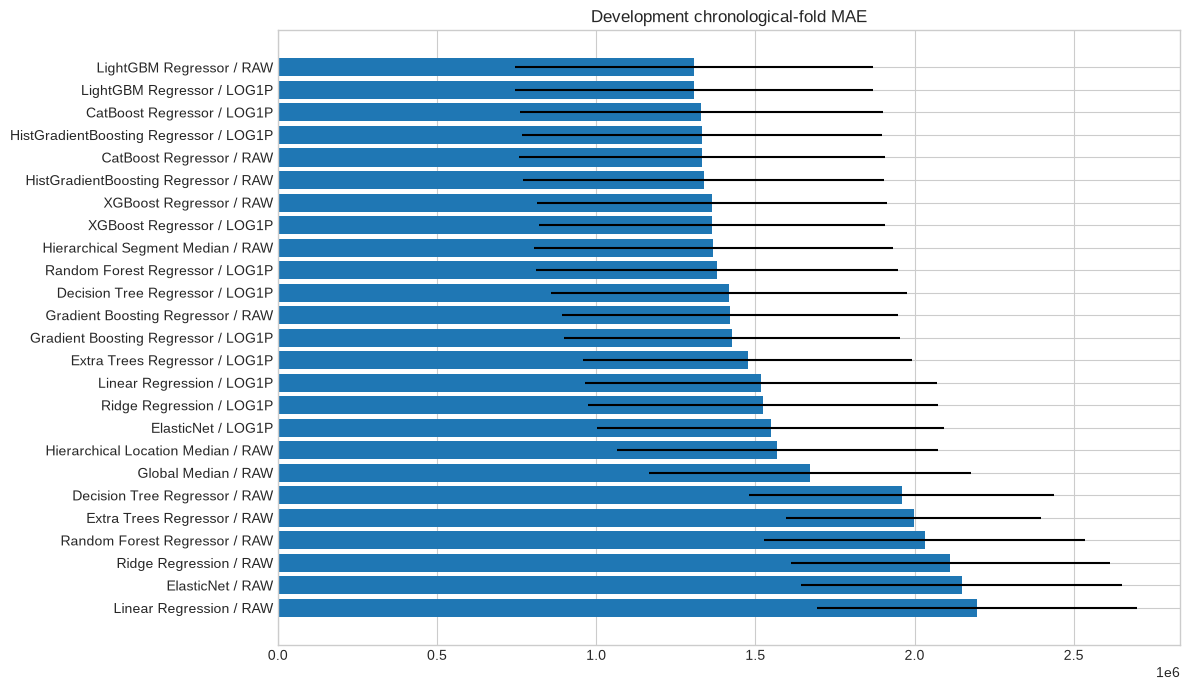

In [ ]:
development_rows=[]
for baseline in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']: development_rows+=evaluate_config(baseline,{},SELECTED_FEATURES,'TRAIN-ONLY BASELINE','RAW')
for name in MODEL_ORDER:
 for transform in ['RAW','LOG1P']: development_rows+=evaluate_config(name,BASE_PARAMS[name],SELECTED_FEATURES,SELECTED_FEATURE_SET,transform)
development_fold_results=pd.DataFrame(development_rows); development_comparison=summarize_development(development_fold_results)
display(development_comparison); assert not TEST_ACCESSED_FOR_SELECTION
fig,ax=plt.subplots(figsize=(12,7)); plot=development_comparison.sort_values('MAE_Mean',ascending=False); ax.barh(plot.Model+' / '+plot['Target Transform'],plot.MAE_Mean,xerr=plot.MAE_Std); ax.set_title('Development chronological-fold MAE'); plt.tight_layout(); plt.show()

## 07 Small bounded tuning and candidate lock

Only the best development configuration per family enters a small bounded refinement. No TEST identities or metrics are accessed.

In [ ]:
best_family=development_comparison.sort_values('MAE_Mean').drop_duplicates('Model'); ml_shortlist=best_family.loc[~best_family.Model.isin(['Global Median','Hierarchical Location Median','Hierarchical Segment Median'])].head(3)
TUNING={
'CatBoost Regressor':[BASE_PARAMS['CatBoost Regressor'],{**BASE_PARAMS['CatBoost Regressor'],'depth':6,'iterations':200}],
'LightGBM Regressor':[BASE_PARAMS['LightGBM Regressor'],{**BASE_PARAMS['LightGBM Regressor'],'num_leaves':63,'n_estimators':180}],
'XGBoost Regressor':[BASE_PARAMS['XGBoost Regressor'],{**BASE_PARAMS['XGBoost Regressor'],'max_depth':5,'n_estimators':160}],
'HistGradientBoosting Regressor':[BASE_PARAMS['HistGradientBoosting Regressor'],{**BASE_PARAMS['HistGradientBoosting Regressor'],'max_iter':160,'max_leaf_nodes':63}],
'Random Forest Regressor':[BASE_PARAMS['Random Forest Regressor'],{**BASE_PARAMS['Random Forest Regressor'],'n_estimators':140}],
'Extra Trees Regressor':[BASE_PARAMS['Extra Trees Regressor'],{**BASE_PARAMS['Extra Trees Regressor'],'n_estimators':140}]}
tuning_rows=[]
for _,row in ml_shortlist.iterrows():
 for params in TUNING.get(row['Model'],[BASE_PARAMS[row['Model']]]): tuning_rows+=evaluate_config(row['Model'],params,SELECTED_FEATURES,SELECTED_FEATURE_SET,row['Target Transform'])
tuning_fold_results=pd.DataFrame(tuning_rows); tuning_summary=summarize_development(tuning_fold_results)
candidate_pool=pd.concat([development_comparison.loc[development_comparison.Model.str.contains('Median')],tuning_summary],ignore_index=True)
COMPLEXITY={'Global Median':0,'Hierarchical Location Median':1,'Hierarchical Segment Median':2,'Linear Regression':3,'Ridge Regression':4,'ElasticNet':5,'Decision Tree Regressor':6,'HistGradientBoosting Regressor':7,'Gradient Boosting Regressor':8,'Random Forest Regressor':9,'Extra Trees Regressor':10,'LightGBM Regressor':11,'XGBoost Regressor':12,'CatBoost Regressor':13}
LOCKED_CANDIDATE=lock_candidate(candidate_pool,COMPLEXITY,tolerance=.01)
LOCKED_MODEL=LOCKED_CANDIDATE.Model; LOCKED_TRANSFORM=LOCKED_CANDIDATE['Target Transform']; LOCKED_PARAMS=json.loads(LOCKED_CANDIDATE.Parameters)
assert not TEST_ACCESSED_FOR_SELECTION
locked_fold_report=tuning_fold_results.loc[(tuning_fold_results.Model.eq(LOCKED_MODEL))&(tuning_fold_results.Parameters.eq(json.dumps(LOCKED_PARAMS,sort_keys=True)))].sort_values('Fold')
assert locked_fold_report['Group Overlap'].eq(0).all()
display(tuning_summary); display(locked_fold_report[['Fold','Train Start','Train End','Validation Start','Validation End','Train Rows','Validation Rows','Train Groups','Validation Groups','Group Overlap','Target Median','Target P95','Target Max','MAE']]); display(LOCKED_CANDIDATE.to_frame('Locked development decision')); display(Markdown(f'### Locked before TEST: **{LOCKED_MODEL} / {LOCKED_TRANSFORM}**'))

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
5,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.299594e+06,1.008322e+06,567838.249095,651369.066645,0.389871,2.451162
4,LightGBM Regressor,RAW,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306582e+06,1.024405e+06,561874.192771,656723.173235,0.390601,0.714847
3,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,1.314398e+06,1.025188e+06,572878.534583,672785.528875,0.392312,0.933902
0,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 6, ""iterations"": 200, ""l2_leaf_reg"":...",3,1.314531e+06,1.021293e+06,568425.875617,671520.332864,0.392135,2.364486
1,CatBoost Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""depth"": 7, ""iterations"": 140, ""l2_leaf_reg"":...",3,1.330772e+06,1.043190e+06,568905.575921,688004.719867,0.394837,1.364740
2,HistGradientBoosting Regressor,LOG1P,F4 — AREA + SOURCE + LOCATION,"{""learning_rate"": 0.07, ""loss"": ""absolute_erro...",3,1.331921e+06,1.054486e+06,566393.526592,692366.088978,0.394762,0.438166


,Fold,Train Start,Train End,Validation Start,Validation End,Train Rows,Validation Rows,Train Groups,Validation Groups,Group Overlap,Target Median,Target P95,Target Max,MAE
0,1,2026-09-20 12:48:44,2026-09-26 15:16:31,2026-09-26 15:16:40,2026-09-27 15:49:05,58900,15890,58092,15843,0,4000000.0,6500000.0,8.500000e+09,1.953620e+06
1,2,2026-09-20 12:48:44,2026-09-27 15:49:02,2026-09-27 15:49:05,2026-09-28 16:05:51,74789,15994,73934,15845,0,3500000.0,6000000.0,7.000000e+07,9.417213e+05
2,3,2026-09-20 12:48:44,2026-09-28 16:05:51,2026-09-28 16:05:53,2026-09-29 12:38:36,90783,17890,89779,15841,0,4000000.0,7000000.0,2.500000e+08,1.024405e+06


,Locked development decision
Model,LightGBM Regressor
Target Transform,RAW
Feature Set,F4 — AREA + SOURCE + LOCATION
Parameters,"{""learning_rate"": 0.05, ""min_child_samples"": 3..."
Folds,3
MAE_Mean,1306582.13772
MAE_Median,1024405.154457
MAE_Std,561874.192771
MedianAE_Mean,656723.173235
RMSLE_Mean,0.390601


### Locked before TEST: **LightGBM Regressor / RAW**

## 08 Source ablation and leave-one-source-out diagnostics (development only)

In [ ]:
ablation_rows=[]
NO_SOURCE_FEATURES=[f for f in SELECTED_FEATURES if f!='source_code']
for label,features in [('Without source_code',NO_SOURCE_FEATURES),('With source_code',SELECTED_FEATURES)]: ablation_rows+=evaluate_config(LOCKED_MODEL,LOCKED_PARAMS,features,label,LOCKED_TRANSFORM)
source_ablation=summarize_development(pd.DataFrame(ablation_rows)); without=source_ablation.loc[source_ablation['Feature Set'].eq('Without source_code')].iloc[0]; with_source=source_ablation.loc[source_ablation['Feature Set'].eq('With source_code')].iloc[0]
SOURCE_ABLATION_ABSOLUTE=without.MAE_Mean-with_source.MAE_Mean; SOURCE_ABLATION_PERCENT=SOURCE_ABLATION_ABSOLUTE/with_source.MAE_Mean*100
display(source_ablation); display(pd.Series({'Absolute MAE degradation':SOURCE_ABLATION_ABSOLUTE,'MAE degradation %':SOURCE_ABLATION_PERCENT},name='Value').to_frame())
loso=[]
for source in sorted(development_df.source_code.dropna().unique()):
 train=development_df.loc[development_df.source_code.ne(source)]; score=development_df.loc[development_df.source_code.eq(source)]
 if len(score)<100: continue
 if LOCKED_MODEL in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']: pred=baseline_predict(LOCKED_MODEL,train,score)
 else: _,pred,_,_=fit_predict(LOCKED_MODEL,LOCKED_PARAMS,SELECTED_FEATURES,train,score,LOCKED_TRANSFORM)
 base=baseline_predict('Global Median',train,score); metrics=regression_metrics(score[TARGET],pred)
 loso.append({'Held-out Source':source,'Rows':len(score),'Target Median':score[TARGET].median(),'Target P95':score[TARGET].quantile(.95),'Target Max':score[TARGET].max(),**metrics,'Global Median MAE':regression_metrics(score[TARGET],base)['MAE'],'Baseline Beats Locked':regression_metrics(score[TARGET],base)['MAE']<metrics['MAE']})
leave_one_source_out=pd.DataFrame(loso).sort_values('MAE'); display(leave_one_source_out)

,Model,Target Transform,Feature Set,Parameters,Folds,MAE_Mean,MAE_Median,MAE_Std,MedianAE_Mean,RMSLE_Mean,Fit_Time_Mean
0,LightGBM Regressor,RAW,With source_code,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.306582e+06,1.024405e+06,561874.192771,656723.173235,0.390601,0.728646
1,LightGBM Regressor,RAW,Without source_code,"{""learning_rate"": 0.05, ""min_child_samples"": 3...",3,1.433480e+06,1.119025e+06,582180.586378,757183.716057,0.426352,1.584782


,Value
Absolute MAE degradation,126898.071298
MAE degradation %,9.712215


,Held-out Source,Rows,Target Median,Target P95,Target Max,MAE,Median AE,RMSE,RMSLE,R²,Negative Predictions,Global Median MAE,Baseline Beats Locked
3,muaban,1328,4000000.0,6800000.0,1.270000e+07,1.099915e+06,8.173460e+05,1.541870e+06,0.355871,-0.083207,0,1.061190e+06,True
0,cafeland,8134,4200000.0,9000000.0,9.500000e+07,1.436301e+06,7.564945e+05,2.920198e+06,0.481040,-0.113960,0,1.554964e+06,False
5,nhatrovn,746,4500000.0,7500000.0,9.000000e+06,1.532648e+06,1.311020e+06,1.900626e+06,0.443568,-0.525414,0,1.283458e+06,True
2,mogi,8606,3000000.0,6000000.0,4.000000e+09,1.651142e+06,8.259653e+05,4.312488e+07,0.580133,-0.000147,0,1.950686e+06,False
7,tromoi,149,2000000.0,7000000.0,1.360000e+07,1.945247e+06,2.110894e+06,2.278904e+06,0.718687,-0.238498,0,1.907718e+06,True
6,phongtro123,55489,3500000.0,6000000.0,3.800000e+10,2.327228e+06,7.122770e+05,1.700974e+08,0.503908,-0.000041,0,2.917657e+06,False
1,chothuephongtro,31649,6000000.0,10000000.0,2.350000e+07,2.462179e+06,1.934604e+06,3.189609e+06,0.634999,-0.544722,0,2.851228e+06,False
4,nhatot,2498,3700000.0,6500000.0,4.000000e+09,2.667460e+06,6.661306e+05,8.006989e+07,0.522767,-0.000489,0,2.884568e+06,False


## 09 FINAL TEST — ONE-TIME EVALUATION

The candidate above is immutable. It is now retrained on all development rows and evaluated once on the sealed future TEST. Baselines are evaluated on the identical TEST rows.

In [ ]:
assert LOCKED_MODEL and not TEST_ACCESSED_FOR_SELECTION
TEST_ACCESSED_FOR_SELECTION=True
test_predictions=pd.DataFrame({'rental_post_id':test_df.rental_post_id.to_numpy(),'group_key':test_df.group_key.to_numpy(),'actual_price':test_df[TARGET].to_numpy(float),'source_code':test_df.source_code.to_numpy(),'ward_current':test_df.ward_current.to_numpy(),'district_text_extracted':test_df.district_text_extracted.to_numpy(),'province_text_extracted':test_df.province_text_extracted.to_numpy(),'area_value_clean':test_df.area_value_clean.to_numpy(),'ward_mapping_status':test_df.ward_mapping_status.to_numpy(),'parse_status':test_df.parse_status.to_numpy(),'title_clean':test_df.title_clean.to_numpy(),'latest_observed_at':test_df.latest_observed_at.to_numpy()})
final_rows=[]; final_model=None
for name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
 pred=baseline_predict(name,development_df,test_df); test_predictions[name]=pred; final_rows.append({'Model':name,'Target Transform':'RAW',**regression_metrics(test_df[TARGET],pred)})
if LOCKED_MODEL in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']:
 locked_pred=baseline_predict(LOCKED_MODEL,development_df,test_df)
else:
 final_model,locked_pred,fit_s,pred_s=fit_predict(LOCKED_MODEL,LOCKED_PARAMS,SELECTED_FEATURES,development_df,test_df,LOCKED_TRANSFORM)
 test_predictions[LOCKED_MODEL]=locked_pred; final_rows.append({'Model':LOCKED_MODEL,'Target Transform':LOCKED_TRANSFORM,**regression_metrics(test_df[TARGET],locked_pred),'Fit Time':fit_s,'Prediction Time':pred_s})
final_test=pd.DataFrame(final_rows).drop_duplicates('Model').sort_values('MAE'); display(final_test)
assert len(test_predictions)==len(test_df)==test_predictions.rental_post_id.nunique()

,Model,Target Transform,MAE,Median AE,RMSE,RMSLE,R²,Negative Predictions,Fit Time,Prediction Time
3,LightGBM Regressor,RAW,9.471114e+05,635311.220719,1.729721e+06,0.439354,0.186482,0,0.964051,0.01756
2,Hierarchical Segment Median,RAW,1.016269e+06,700000.000000,1.803175e+06,0.465392,0.115922,0,NaN,NaN
1,Hierarchical Location Median,RAW,1.196465e+06,900000.000000,1.922147e+06,0.515513,-0.004589,0,NaN,NaN
0,Global Median,RAW,1.232577e+06,1000000.000000,1.934469e+06,0.514820,-0.017510,0,NaN,NaN


## 10 Tail, segment, prediction-sanity, and largest-error diagnostics

,Model,Region,Count,MAE,RMSE,Squared Error Contribution %
0,Hierarchical Segment Median,Central ≤ dev P95,18643,9.733125e+05,1.373813e+06,57.863823
1,Hierarchical Segment Median,Extreme > dev P99,59,1.458983e+07,2.083931e+07,42.136177
2,LightGBM Regressor,Central ≤ dev P95,18643,9.035002e+05,1.272899e+06,53.983799
3,LightGBM Regressor,Extreme > dev P99,59,1.472753e+07,2.089053e+07,46.016201


,Dimension,Segment,Count,Small Sample (<100),Baseline MAE,Locked MAE,Baseline Beats Locked
15,Area Band,"(25.0, 28.0]",1015,False,7.650409e+05,7.112198e+05,False
13,Area Band,"(-inf, 20.0]",5590,False,8.239899e+05,7.333674e+05,False
14,Area Band,"(20.0, 25.0]",4646,False,8.481549e+05,8.214224e+05,False
16,Area Band,"(28.0, 30.0]",3308,False,9.732524e+05,9.584563e+05,False
19,Area Band,nan,436,False,1.159358e+06,1.080639e+06,False
17,Area Band,"(30.0, 35.0]",1526,False,1.217997e+06,1.170841e+06,False
18,Area Band,"(35.0, inf]",2181,False,1.879622e+06,1.672032e+06,False
22,Location Resolution,WARD_RESOLVED,16558,False,9.935130e+05,9.241095e+05,False
20,Location Resolution,DISTRICT_ONLY,333,False,1.222207e+06,1.080976e+06,False
21,Location Resolution,UNRESOLVED,1811,False,1.186461e+06,1.132804e+06,False


,Model,Pred Min,Pred Median,Pred P95,Pred P99,Pred Max,Actual Min,Actual Max,Negative,Zero,Outside 100k–100m
0,Hierarchical Segment Median,750000.000000,3.700000e+06,5.450000e+06,6.000000e+06,1.900000e+07,50000.0,95000000.0,0,0,0
1,LightGBM Regressor,830188.121357,3.783902e+06,5.336399e+06,5.751311e+06,7.862240e+06,50000.0,95000000.0,0,0,0


,rental_post_id,actual_price,predicted_price,absolute_error,source_code,area_value_clean,ward_current,district_text_extracted,title_clean
11402,215434,95000000.0,4.170546e+06,9.082945e+07,phongtro123,900.0,Phường Cầu Ông Lãnh,NaN,"CHO THUÊ 12 PHÒNG | SỐ 8 NGUYỄN THÁI HỌC, Q1 |..."
1187,79792,60000000.0,7.258045e+06,5.274195e+07,cafeland,99.0,Phường Tân Bình,NaN,Phòng trọ: Cho thuê 16 phòng căn hộ dịch vụ kh...
2043,82133,52800000.0,7.277841e+06,4.552216e+07,cafeland,200.0,NaN,NaN,Phòng trọ: Cho thuê 21p khách sạn mặt tiền QL ...
10353,119753,48000000.0,4.490689e+06,4.350931e+07,phongtro123,35.0,Phường Tân Thuận,Quận 7,CHO THUÊ PHÒNG CÓ CỬA SỔ HƯỚNG NẮNG - CÓ GÁC C...
14487,224167,42000000.0,3.999534e+06,3.800047e+07,phongtro123,35.0,NaN,NaN,Cho thuê phòng full nội thất khu sân bay đầy đ...
11024,215038,40000000.0,2.432863e+06,3.756714e+07,phongtro123,15.0,Phường Hiệp Bình,NaN,Đầu tư phòng trọ giá rẻ tại Thủ Đức !
8762,114400,35000000.0,3.751831e+06,3.124817e+07,phongtro123,40.0,Phường Thủ Đức,NaN,"CHO THUE NHA CAP 4 GAN DAI HOC NGAN HANG, CAO ..."
12092,216616,32000000.0,3.393421e+06,2.860658e+07,phongtro123,18.0,Phường Thạnh Mỹ Tây,NaN,Phòng dành cho 2 đến 3 bạn tại 135/1/9 nguyễn ...
18632,548342,28000000.0,3.495161e+06,2.450484e+07,muaban,NaN,Phường Bình Hưng Hòa,Quận Bình Tân,KHAI TRƯƠNG DỰ ÁN MỚI FULL NỘI THẤT NGAY NGUYỄ...
16138,228105,27000000.0,3.172541e+06,2.382746e+07,phongtro123,25.0,Phường Đông Hưng Thuận,NaN,Cho thuê phòng trọ mới xây gần cầu Tham Lương


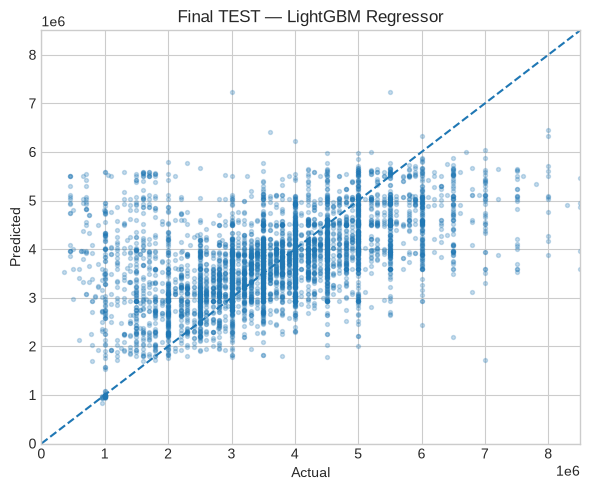

In [ ]:
baseline_name='Hierarchical Segment Median'; names=list(dict.fromkeys([baseline_name,LOCKED_MODEL])); dev_p95=development_df[TARGET].quantile(.95); dev_p99=development_df[TARGET].quantile(.99)
diagnostics=[]
for name in names:
 pred=test_predictions[name]; actual=test_predictions.actual_price; ae=(actual-pred).abs(); se=(actual-pred)**2
 regions=[('Central ≤ dev P95',actual<=dev_p95)]
 if dev_p99>dev_p95: regions.append(('Upper P95–P99',(actual>dev_p95)&(actual<=dev_p99)))
 regions.append(('Extreme > dev P99',actual>dev_p99))
 for region,mask in regions:
  diagnostics.append({'Model':name,'Region':region,'Count':int(mask.sum()),'MAE':ae[mask].mean(),'RMSE':np.sqrt(se[mask].mean()),'Squared Error Contribution %':se[mask].sum()/se.sum()*100})
tail_diagnostics=pd.DataFrame(diagnostics); display(tail_diagnostics)
price_band,price_edges=unique_price_bands(development_df[TARGET],test_predictions.actual_price); _,_,area_edges=add_train_only_area_band(development_df,test_df); area_band=pd.cut(test_predictions.area_value_clean,area_edges,include_lowest=True); location_resolution=np.where(test_predictions.ward_current.notna(),'WARD_RESOLVED',np.where(test_predictions.district_text_extracted.notna(),'DISTRICT_ONLY','UNRESOLVED'))
segments=[]
segment_dimensions={'Price Band':price_band,'Source':test_predictions.source_code,'Area Band':area_band,'Location Resolution':location_resolution}
for dimension,values in segment_dimensions.items():
 for segment,idx in pd.Series(values,index=test_predictions.index).groupby(values,dropna=False,observed=False).groups.items():
  small=len(idx)<100
  base=(test_predictions.loc[idx,'actual_price']-test_predictions.loc[idx,baseline_name]).abs().mean(); ml=(test_predictions.loc[idx,'actual_price']-test_predictions.loc[idx,LOCKED_MODEL]).abs().mean()
  segments.append({'Dimension':dimension,'Segment':str(segment),'Count':len(idx),'Small Sample (<100)':small,'Baseline MAE':base,'Locked MAE':ml,'Baseline Beats Locked':base<ml})
segment_diagnostics=pd.DataFrame(segments); display(segment_diagnostics.sort_values(['Dimension','Locked MAE']))
plausible_min,plausible_max=100_000,100_000_000
sanity=pd.DataFrame([{'Model':n,'Pred Min':test_predictions[n].min(),'Pred Median':test_predictions[n].median(),'Pred P95':test_predictions[n].quantile(.95),'Pred P99':test_predictions[n].quantile(.99),'Pred Max':test_predictions[n].max(),'Actual Min':test_predictions.actual_price.min(),'Actual Max':test_predictions.actual_price.max(),'Negative':int((test_predictions[n]<0).sum()),'Zero':int((test_predictions[n]==0).sum()),'Outside 100k–100m':int(((test_predictions[n]<plausible_min)|(test_predictions[n]>plausible_max)).sum())} for n in names]); display(sanity)
largest=test_predictions.assign(predicted_price=test_predictions[LOCKED_MODEL],absolute_error=(test_predictions.actual_price-test_predictions[LOCKED_MODEL]).abs()).nlargest(25,'absolute_error'); display(largest[['rental_post_id','actual_price','predicted_price','absolute_error','source_code','area_value_clean','ward_current','district_text_extracted','title_clean']])
fig,ax=plt.subplots(figsize=(6,5)); sample=test_predictions.sample(min(5000,len(test_predictions)),random_state=SEED); limit=test_predictions.actual_price.quantile(.99); ax.scatter(sample.actual_price,sample[LOCKED_MODEL],s=8,alpha=.25); ax.plot([0,limit],[0,limit],'--'); ax.set(xlim=(0,limit),ylim=(0,limit),xlabel='Actual',ylabel='Predicted',title=f'Final TEST — {LOCKED_MODEL}'); plt.tight_layout(); plt.show()

## 11 Locked-model feature importance and final verdict

,Feature,Gain,Split Count,Gain %
0,source_code,207023.527785,467,35.006918
1,ward_current,175024.729452,1210,29.596038
2,area_value_clean,171865.899022,1337,29.061892
3,district_text_extracted,37464.753827,586,6.335152


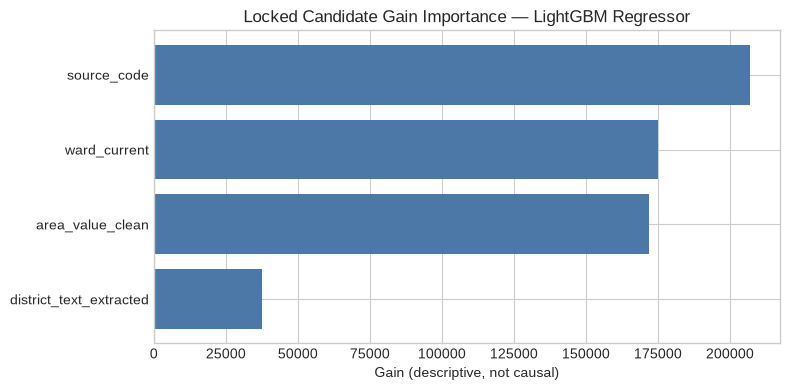

,Criterion,Current Runtime Result
0,Locked candidate,LightGBM Regressor
1,Target transform,RAW
2,Feature set,F4 — AREA + SOURCE + LOCATION
3,TEST MAE,947111.4494
4,TEST MedianAE,635311.220719
5,TEST RMSE,1729720.77963
6,TEST RMSLE,0.439354
7,TEST R²,0.186482
8,Improvement vs Global Median %,23.160045
9,Improvement vs Location Median %,20.840862


In [ ]:
if LOCKED_MODEL=='LightGBM Regressor':
 feature_importance=lightgbm_gain_importance(final_model,SELECTED_FEATURES)
else:
 feature_importance=pd.DataFrame({'Feature':SELECTED_FEATURES,'Gain':np.nan,'Split Count':np.nan,'Gain %':np.nan})
display(feature_importance)
if feature_importance.Gain.notna().any():
 plot=feature_importance.sort_values('Gain'); fig,ax=plt.subplots(figsize=(8,4)); ax.barh(plot.Feature,plot.Gain,color='#4C78A8'); ax.set(title=f'Locked Candidate Gain Importance — {LOCKED_MODEL}',xlabel='Gain (descriptive, not causal)'); plt.tight_layout(); plt.show()
final_locked=final_test.loc[final_test.Model.eq(LOCKED_MODEL)].iloc[0]
baseline_metrics={name:final_test.loc[final_test.Model.eq(name)].iloc[0] for name in ['Global Median','Hierarchical Location Median','Hierarchical Segment Median']}
locked_dev=candidate_pool.loc[(candidate_pool.Model.eq(LOCKED_MODEL))&(candidate_pool.Parameters.eq(json.dumps(LOCKED_PARAMS,sort_keys=True)))].sort_values('MAE_Mean').iloc[0]
tail_locked=tail_diagnostics.loc[tail_diagnostics.Model.eq(LOCKED_MODEL)]; extreme=tail_locked.loc[tail_locked.Region.str.startswith('Extreme')].iloc[0]; central=tail_locked.loc[tail_locked.Region.str.startswith('Central')].iloc[0]
readiness='experimental/prototype-ready; not production-ready' if (locked_dev.MAE_Std/locked_dev.MAE_Mean>.15 or (model_df.latest_observed_at.max()-model_df.latest_observed_at.min()).days<30 or extreme['Squared Error Contribution %']>50) else 'production-candidate pending operational validation'
verdict=pd.DataFrame([
 ['Locked candidate',LOCKED_MODEL],['Target transform',LOCKED_TRANSFORM],['Feature set',SELECTED_FEATURE_SET],['TEST MAE',final_locked.MAE],['TEST MedianAE',final_locked['Median AE']],['TEST RMSE',final_locked.RMSE],['TEST RMSLE',final_locked.RMSLE],['TEST R²',final_locked['R²']],
 ['Improvement vs Global Median %',(baseline_metrics['Global Median'].MAE-final_locked.MAE)/baseline_metrics['Global Median'].MAE*100],['Improvement vs Location Median %',(baseline_metrics['Hierarchical Location Median'].MAE-final_locked.MAE)/baseline_metrics['Hierarchical Location Median'].MAE*100],['Improvement vs Strong Segment Median %',(baseline_metrics['Hierarchical Segment Median'].MAE-final_locked.MAE)/baseline_metrics['Hierarchical Segment Median'].MAE*100],
 ['Development MAE mean',locked_dev.MAE_Mean],['Development MAE median',locked_dev.MAE_Median],['Development MAE std',locked_dev.MAE_Std],['Source ablation degradation %',SOURCE_ABLATION_PERCENT],['Extreme-tail squared error share %',extreme['Squared Error Contribution %']],['Central-population MAE',central.MAE],['Readiness',readiness],['Limitation','~10-day short-horizon temporal evidence only']
 ],columns=['Criterion','Current Runtime Result']); display(verdict)

## 12 Persist auditable benchmark evidence

In [ ]:
ARTIFACT_DIR=PROJECT_ROOT/'data'/'modeling'/'roombeacon_price_benchmark_v3'; ARTIFACT_DIR.mkdir(parents=True,exist_ok=True)
tables={'semantic_population_summary.csv':semantic_population_summary,'semantic_exclusion_summary.csv':semantic_exclusion_summary,'semantic_exclusion_examples.csv':semantic_exclusion_examples,'target_distribution_comparison.csv':target_distribution_comparison,'valid_high_price_examples.csv':valid_high_price_examples,'development_fold_results.csv':development_fold_results,'development_comparison.csv':development_comparison,'feature_fold_results.csv':feature_fold_results,'feature_summary.csv':feature_summary,'f4_f5_decision.csv':f45_decision,'tuning_fold_results.csv':tuning_fold_results,'tuning_summary.csv':tuning_summary,'source_ablation.csv':source_ablation,'leave_one_source_out.csv':leave_one_source_out,'final_test.csv':final_test,'tail_diagnostics.csv':tail_diagnostics,'segment_diagnostics.csv':segment_diagnostics,'prediction_sanity.csv':sanity,'feature_importance.csv':feature_importance,'final_verdict.csv':verdict}
for filename,table in tables.items(): table.to_csv(ARTIFACT_DIR/filename,index=False)
with duckdb.connect(':memory:') as con: con.register('_pred',test_predictions); con.execute('copy _pred to ? (format parquet)',[str(ARTIFACT_DIR/'test_predictions.parquet')])
metadata={'benchmark':'roombeacon_price_benchmark_v3','generated_at':datetime.now(timezone.utc).astimezone().isoformat(),'versions':versions,'hardware':{'platform':platform.platform(),'processor':platform.processor(),'cpu_count':__import__('os').cpu_count()},'seed':SEED,'silver_path':str(SILVER_PATH),'silver_metadata':silver_metadata,'business_target_definition':BUSINESS_TARGET_DEFINITION,'semantic_eligibility_policy':'Keep numeric/quality-valid rows unless intent is SALE/TRANSFER or scope is WHOLE_BUILDING/MULTI_UNIT_BUSINESS; retain UNKNOWN absent conflicting evidence','eligible_rows':len(model_df),'semantic_excluded_rows':int((numeric_eligible&~semantic_compatible).sum()),'intent_distribution':prepared.listing_intent.value_counts(dropna=False).to_dict(),'scope_distribution':prepared.rental_scope.value_counts(dropna=False).to_dict(),'split_strategy':split_result.strategy,'folds':fold_report.astype(str).to_dict('records'),'selected_feature_set':SELECTED_FEATURE_SET,'locked_candidate':LOCKED_MODEL,'locked_transform':LOCKED_TRANSFORM,'locked_parameters':LOCKED_PARAMS,'categorical_strategy':'LightGBM train-defined pandas categories with explicit __MISSING__/__UNKNOWN__; CatBoost native strings; sklearn fold-fitted unknown-safe encoders','selection_rule':'Development fold MAE mean/median/variability; within 1% prefer lower complexity; then MedianAE/RMSLE/runtime','test_used_for_selection':False,'readiness':readiness,'limitations':['~10-day temporal window','group-level chronology uses representative max timestamp and does not claim row-level isolation','source mix is dataset representation, not market share','extreme target tail retained and reported']}
(ARTIFACT_DIR/'experiment_metadata.json').write_text(json.dumps(metadata,indent=2,ensure_ascii=False),encoding='utf-8')
display(pd.DataFrame([{'Artifact':p.name,'Bytes':p.stat().st_size} for p in sorted(ARTIFACT_DIR.iterdir())])); display(Markdown('**Benchmark V3 complete. Candidate was locked before the one-time final TEST evaluation.**'))

,Artifact,Bytes
0,development_comparison.csv,6089
1,development_fold_results.csv,30353
2,experiment_metadata.json,8950
3,f4_f5_decision.csv,273
4,feature_fold_results.csv,9640
5,feature_importance.csv,263
6,feature_summary.csv,2095
7,final_test.csv,610
8,final_verdict.csv,816
9,leave_one_source_out.csv,1491


**Benchmark V3 complete. Candidate was locked before the one-time final TEST evaluation.**